In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [5]:
states = ["Browse", "Search", "Click", "Purchase", "Exit"]

print(states)

['Browse', 'Search', 'Click', 'Purchase', 'Exit']


In [6]:
transition_matrix = np.array([
    [0.2, 0.5, 0.2, 0.0, 0.1],  # From Browse
    [0.1, 0.2, 0.4, 0.1, 0.2],  # From Search
    [0.0, 0.1, 0.3, 0.2, 0.4],  # From Click
    [0.0, 0.0, 0.0, 1.0, 0.0],  # From Purchase
    [0.0, 0.0, 0.0, 0.0, 1.0]   # From Exit
])

print(transition_matrix)

[[0.2 0.5 0.2 0.  0.1]
 [0.1 0.2 0.4 0.1 0.2]
 [0.  0.1 0.3 0.2 0.4]
 [0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  1. ]]


In [7]:
current_state = 0  # Start from "Browse"

state_history = [states[current_state]]

for step in range(10):
    next_state = np.random.choice(
        range(len(states)),
        p=transition_matrix[current_state]
    )

    state_history.append(states[next_state])
    current_state = next_state

print(state_history)

['Browse', 'Browse', 'Search', 'Click', 'Click', 'Click', 'Purchase', 'Purchase', 'Purchase', 'Purchase', 'Purchase']


In [ ]:
num_users = 1000
num_steps = 10

all_user_paths = []

for user in range(num_users):
    current_state = 0  # start from Browse
    user_path = [states[current_state]]

    for step in range(num_steps):
        next_state = np.random.choice(
            range(len(states)),
            p=transition_matrix[current_state]
        )

        user_path.append(states[next_state])
        current_state = next_state

    all_user_paths.append(user_path)

print(all_user_paths[:5])

[['Browse', 'Search', 'Search', 'Browse', 'Browse', 'Browse', 'Browse', 'Browse', 'Click', 'Exit', 'Exit'], ['Browse', 'Search', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit'], ['Browse', 'Search', 'Click', 'Purchase', 'Purchase', 'Purchase', 'Purchase', 'Purchase', 'Purchase', 'Purchase', 'Purchase'], ['Browse', 'Search', 'Purchase', 'Purchase', 'Purchase', 'Purchase', 'Purchase', 'Purchase', 'Purchase', 'Purchase', 'Purchase'], ['Browse', 'Search', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit', 'Exit']]


In [ ]:
final_states = [path[-1] for path in all_user_paths]

state_counts = pd.Series(final_states).value_counts()

print(state_counts)

Exit        719
Purchase    279
Click         2
Name: count, dtype: int64


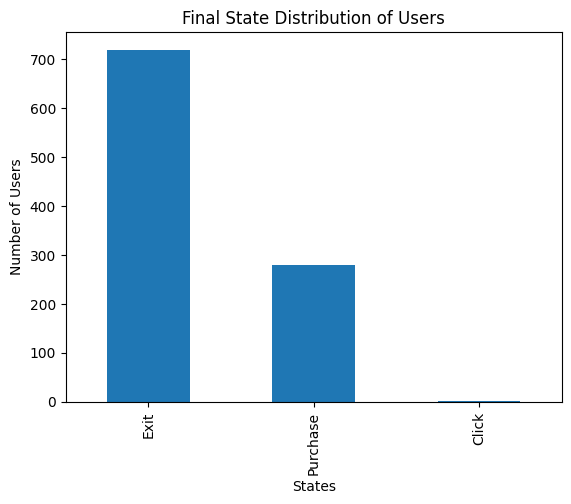

In [ ]:
state_counts.plot(kind='bar')

plt.title("Final State Distribution of Users")
plt.xlabel("States")
plt.ylabel("Number of Users")
plt.show()

In [ ]:
adaptive_matrix = transition_matrix.copy()

state_visit_counts = np.zeros(len(states))

num_users = 1000
num_steps = 10
learning_rate = 0.01


for user in range(num_users):

    current_state = 0

    for step in range(num_steps):

        next_state = np.random.choice(
            range(len(states)),
            p=adaptive_matrix[current_state]
        )

        state_visit_counts[next_state] += 1

        adaptive_matrix[current_state][next_state] += learning_rate

        adaptive_matrix[current_state] /= adaptive_matrix[current_state].sum()

        current_state = next_state


print("Updated Transition Matrix:")
print(adaptive_matrix)

Updated Transition Matrix:
[[1.16685086e-01 6.26138400e-01 2.57159848e-01 0.00000000e+00
  1.66656819e-05]
 [7.16421550e-03 3.00687291e-01 4.11749821e-01 5.51374981e-02
  2.25261174e-01]
 [0.00000000e+00 8.85305703e-03 1.61736501e-01 3.10555213e-01
  5.18855229e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.00000000e+00]]


In [ ]:
adaptive_paths = []

for user in range(num_users):

    current_state = 0
    user_path = [states[current_state]]

    for step in range(num_steps):

        next_state = np.random.choice(
            range(len(states)),
            p=adaptive_matrix[current_state]
        )

        user_path.append(states[next_state])
        current_state = next_state

    adaptive_paths.append(user_path)


adaptive_final_states = [path[-1] for path in adaptive_paths]

adaptive_counts = pd.Series(adaptive_final_states).value_counts()

print(adaptive_counts)

Exit        652
Purchase    348
Name: count, dtype: int64


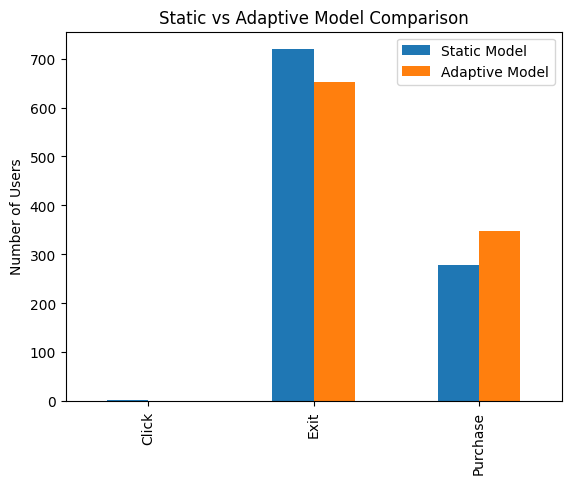

In [ ]:
comparison_df = pd.DataFrame({
    "Static Model": state_counts,
    "Adaptive Model": adaptive_counts
}).fillna(0)

comparison_df.plot(kind="bar")

plt.title("Static vs Adaptive Model Comparison")
plt.ylabel("Number of Users")
plt.show()